In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression,Ridge, Lasso
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data=pd.read_csv("/content/train.csv")
df=pd.DataFrame(data)
print(df.isnull().sum())
print(df.head())
print(df["meal_id"].nunique())
print(df["center_id"].nunique())

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
dtype: int64
        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.86   
3  1338232     1         55     2139          339.50      437.53   
4  1448490     1         55     2631          243.50      242.50   

   emailer_for_promotion  homepage_featured  num_orders  
0                      0                  0         177  
1                      0                  0         270  
2                      0                  0         189  
3                      0                  0          54  
4                      0                  0  

In [3]:
df["discount"] = (df["base_price"] - df["checkout_price"])/df["base_price"]
df = pd.get_dummies(df, columns=["meal_id","center_id"])
df["promo_discount"] =df["discount"] * df["homepage_featured"]*df["emailer_for_promotion"]
X=df.drop(["num_orders","id"],axis=1)
Y=df["num_orders"]
print(X.shape)

(456548, 135)


In [4]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
LinearRegg=LinearRegression()
LinearRegg.fit(X_train,Y_train)
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": LinearRegg.coef_
})

coef_df["abs_coef"] = np.abs(coef_df["coef"])

coef_df = coef_df.sort_values(
    by="abs_coef",
    ascending=False
)
weekly = df.groupby("week")["num_orders"].mean()
print(weekly)
print(coef_df.head(20))
Y_pred=LinearRegg.predict(X_test)
print(mean_squared_error(Y_test,Y_pred))
print(r2_score(Y_train, LinearRegg.predict(X_train)))
print(r2_score(Y_test, Y_pred))

week
1      271.136550
2      271.783149
3      239.828217
4      257.365524
5      419.263729
          ...    
141    237.891511
142    228.431439
143    229.932224
144    242.639915
145    205.607711
Name: num_orders, Length: 145, dtype: float64
            feature        coef    abs_coef
134  promo_discount  926.455112  926.455112
5          discount  907.406737  907.406737
36     meal_id_2290  614.799764  614.799764
28     meal_id_1885  386.081560  386.081560
59     center_id_13  381.928833  381.928833
75     center_id_43  348.785663  348.785663
22     meal_id_1754  334.280356  334.280356
13     meal_id_1248 -327.493210  327.493210
48     meal_id_2631 -311.760625  311.760625
26     meal_id_1847 -283.310456  283.310456
7      meal_id_1109  278.894867  278.894867
43     meal_id_2494 -268.487072  268.487072
57     center_id_10  261.654761  261.654761
15     meal_id_1438 -260.344691  260.344691
52     meal_id_2707  246.919221  246.919221
38     meal_id_2306 -245.544562  245.544562
21 

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
ridge=Ridge()
X_train_scaled,X_test_scaled,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
ridge.fit(X_train_scaled,Y_train)
Y_pred=ridge.predict(X_test_scaled)
print(mean_squared_error(Y_test,Y_pred))
print(r2_score(Y_train, ridge.predict(X_train_scaled)))
print(r2_score(Y_test, Y_pred))

75733.0269323694
0.5003894538082271
0.5034989653313348


In [7]:
lasso=Lasso()
X_train_scaled,X_test_scaled,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
lasso.fit(X_train_scaled,Y_train)
Y_pred=lasso.predict(X_test_scaled)
print(mean_squared_error(Y_test,Y_pred))
print(r2_score(Y_train, lasso.predict(X_train_scaled)))
print(r2_score(Y_test, Y_pred))

82699.82380021251
0.4537782859151853
0.4578250764968176


In [8]:
params={'alpha':[0.01,0.1,1,2,5,10,20]}
ridge_regressor=GridSearchCV(ridge,params,scoring='neg_mean_squared_error',cv=5)
ridge_regressor.fit(X_train_scaled,Y_train)
Y_pred=ridge_regressor.predict(X_test_scaled)
print(ridge_regressor.best_params_)
print(mean_squared_error(Y_test,Y_pred))
print(r2_score(Y_train, ridge_regressor.predict(X_train_scaled)))
print(r2_score(Y_test, Y_pred))

{'alpha': 2}
75732.46493248343
0.5003892686587089
0.5035026497677841


In [9]:
params={'alpha':[0.01,0.1,1,5]}
lasso_regressor=GridSearchCV(lasso,params,scoring='neg_mean_squared_error',cv=5)
lasso_regressor.fit(X_train_scaled,Y_train)
Y_pred=lasso_regressor.predict(X_test_scaled)
print(lasso_regressor.best_params_)
print(mean_squared_error(Y_test,Y_pred))
print(r2_score(Y_train, lasso_regressor.predict(X_train_scaled)))
print(r2_score(Y_test, Y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.219e+09, tolerance: 4.602e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.575e+09, tolerance: 4.542e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.209e+09, tolerance: 4.570e

{'alpha': 0.01}
75731.74303218097
0.5003780780711831
0.5035073825014622


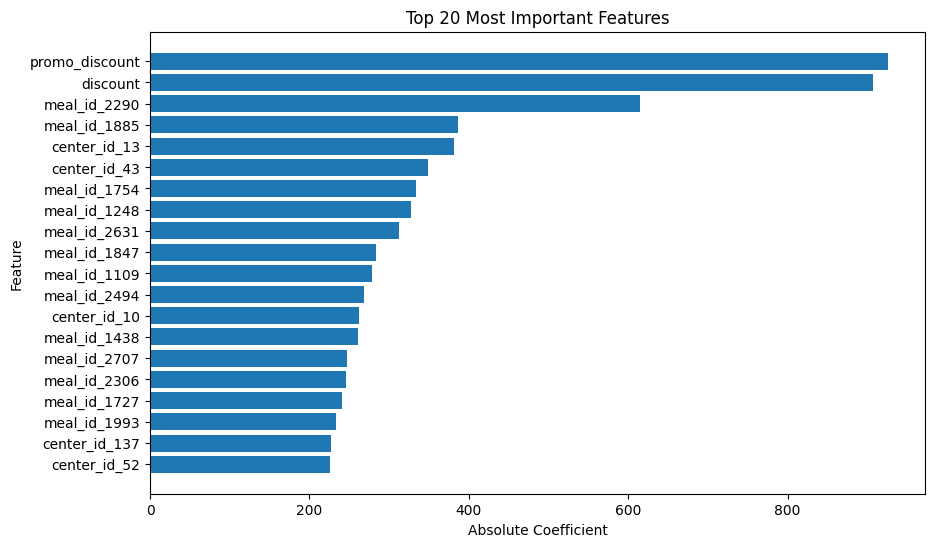

In [10]:

top20 = coef_df.head(20)

plt.figure(figsize=(10,6))
plt.barh(top20["feature"], top20["abs_coef"])
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top 20 Most Important Features")
plt.gca().invert_yaxis()
plt.show()

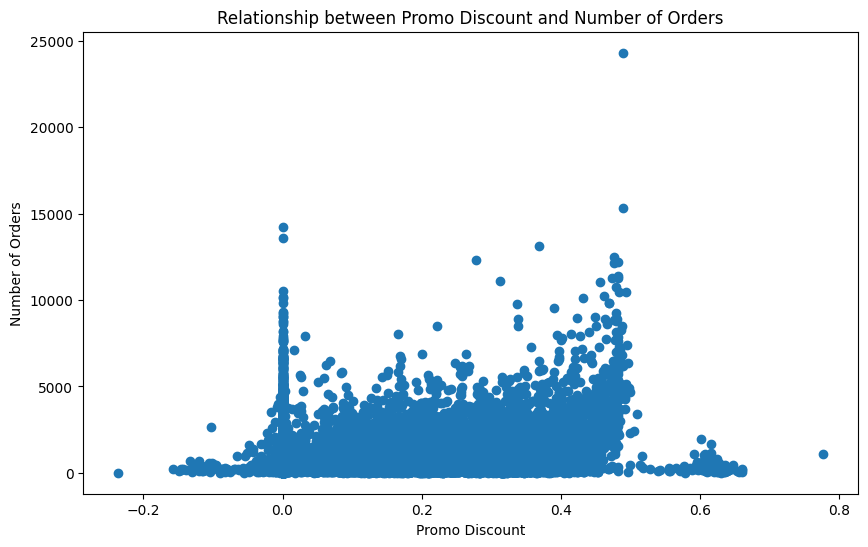

In [11]:
plt.figure(figsize=(10,6))
plt.scatter(df["promo_discount"], df["num_orders"])
plt.xlabel("Promo Discount")
plt.ylabel("Number of Orders")
plt.title("Relationship between Promo Discount and Number of Orders")
plt.show()

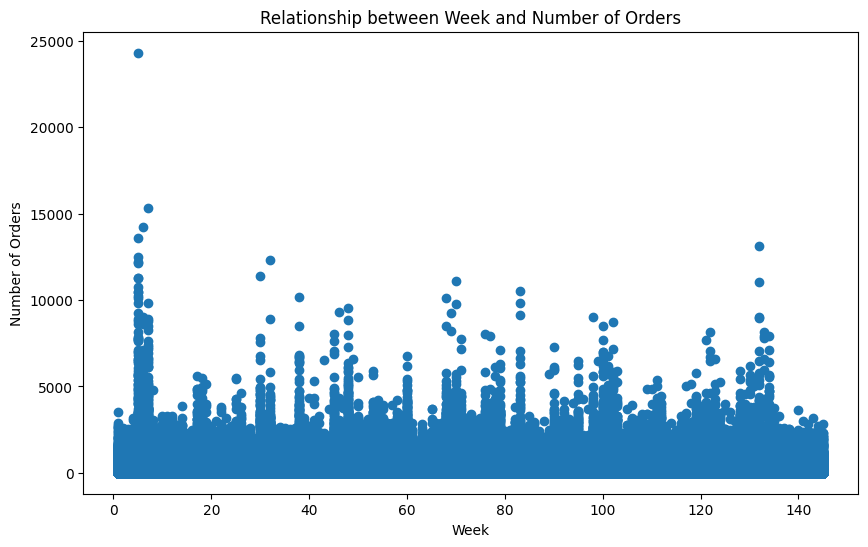

In [12]:
plt.figure(figsize=(10,6))
plt.scatter(df["week"], df["num_orders"])
plt.xlabel("Week")
plt.ylabel("Number of Orders")
plt.title("Relationship between Week and Number of Orders")
plt.show()

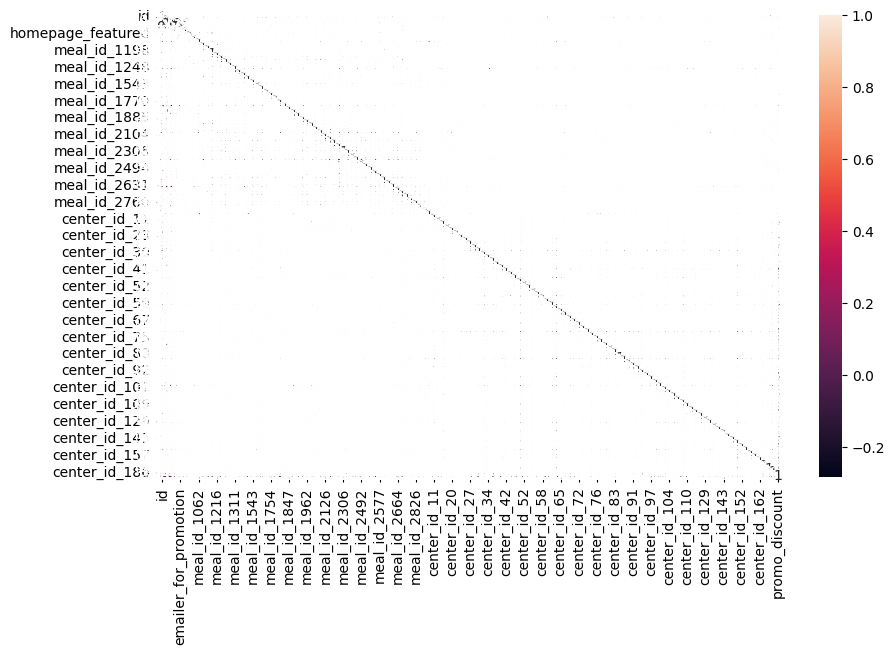

In [13]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr[["num_orders"]]
    .sort_values(by="num_orders", ascending=False),
    annot=True
)

plt.show()

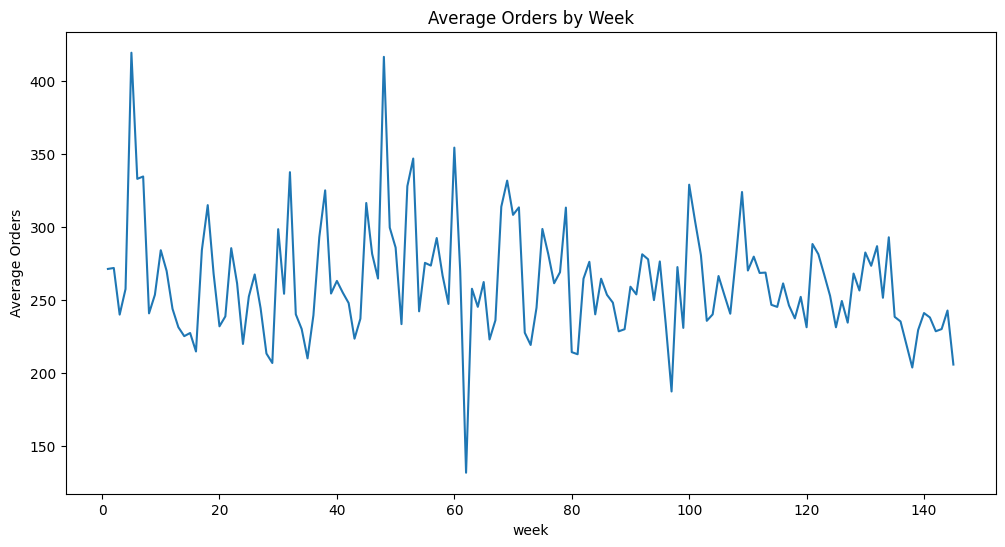

In [15]:
plt.figure(figsize=(12,6))

weekly.plot()

plt.title("Average Orders by Week")
plt.ylabel("Average Orders")

plt.show()

meal_id
1062    423.165574
1109    571.921412
1198    242.101759
1207    166.653341
1216     55.034966
Name: num_orders, dtype: float64
center_id
10    481.969779
11    411.307161
13    609.784984
14    197.832809
17    192.376283
Name: num_orders, dtype: float64


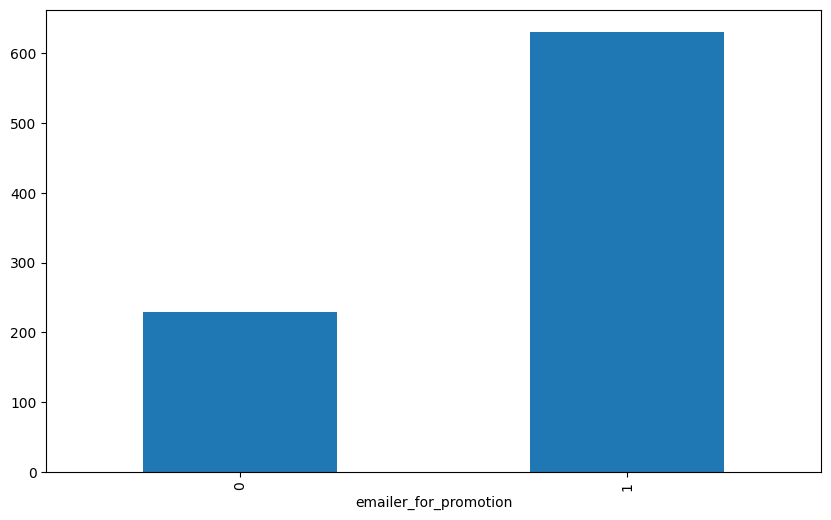

In [23]:
plt.figure(figsize=(10,6))
homepage_orders=df.groupby("homepage_featured")["num_orders"].mean()
email_orders=df.groupby("emailer_for_promotion")["num_orders"].mean()
homepage_orders.plot(kind="bar")
email_orders.plot(kind="bar")
raw_df = pd.read_csv("train.csv")

print(raw_df.groupby("meal_id")["num_orders"].mean().head())
print(raw_df.groupby("center_id")["num_orders"].mean().head())
